# 02 — Exploratory Data Analysis

Six figures, each answering one business question. Deliberately not thirty: a correlation heatmap of one-hot columns looks industrious and says nothing actionable.

**All of this runs on the training split only.** Exploring the test set is a soft leak — every decision made after seeing it (which bands to cut, which features to build) is fitted to it.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
warnings.filterwarnings('ignore')

from src.config import load_config
cfg = load_config()

In [2]:
from src import eda
findings = eda.run(cfg)

training rows            : 5,621
overall churn rate       : 26.45%
churn in first 6 months  : 53.29%
churn at 49-72 months    : 9.24%
month-to-month + 0-6m    : 55.85% (1,094 customers)
electronic check churn   : 45.45%
fiber optic churn        : 41.88%
median monthly, churned  : 79.85
median monthly, stayed   : 64.65

churn by contract:
               churn_rate  customers
Contract                            
Month-to-month     43.07%       3067
One year           10.87%       1214
Two year            2.54%       1340

churn by add-on count (internet customers):
         churn_rate  customers
n_addons                      
0            50.18%        550
1            46.85%        762
2            35.87%        842
3            28.45%        928
4            21.17%        666
5            11.53%        451
6             4.89%        225

[figures] /projects/sandbox/aiml-portfolio/aiml3-churn-explainability/reports/figures


## Q1–Q2: how much churn, and when?

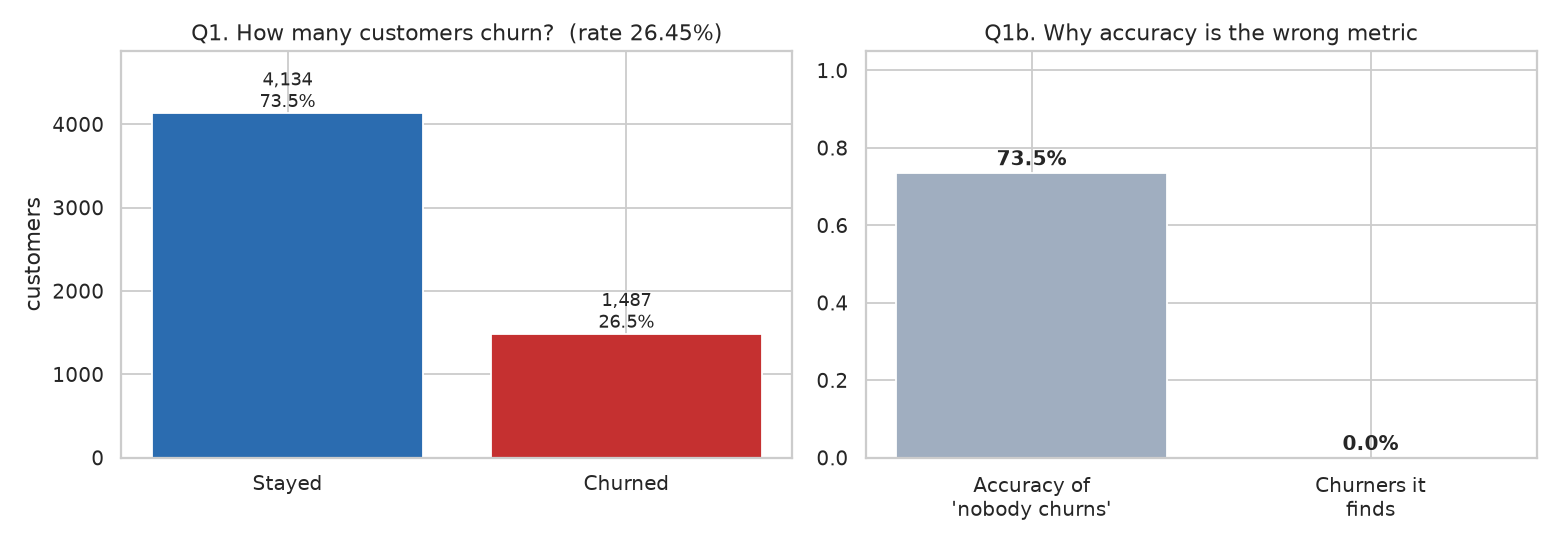

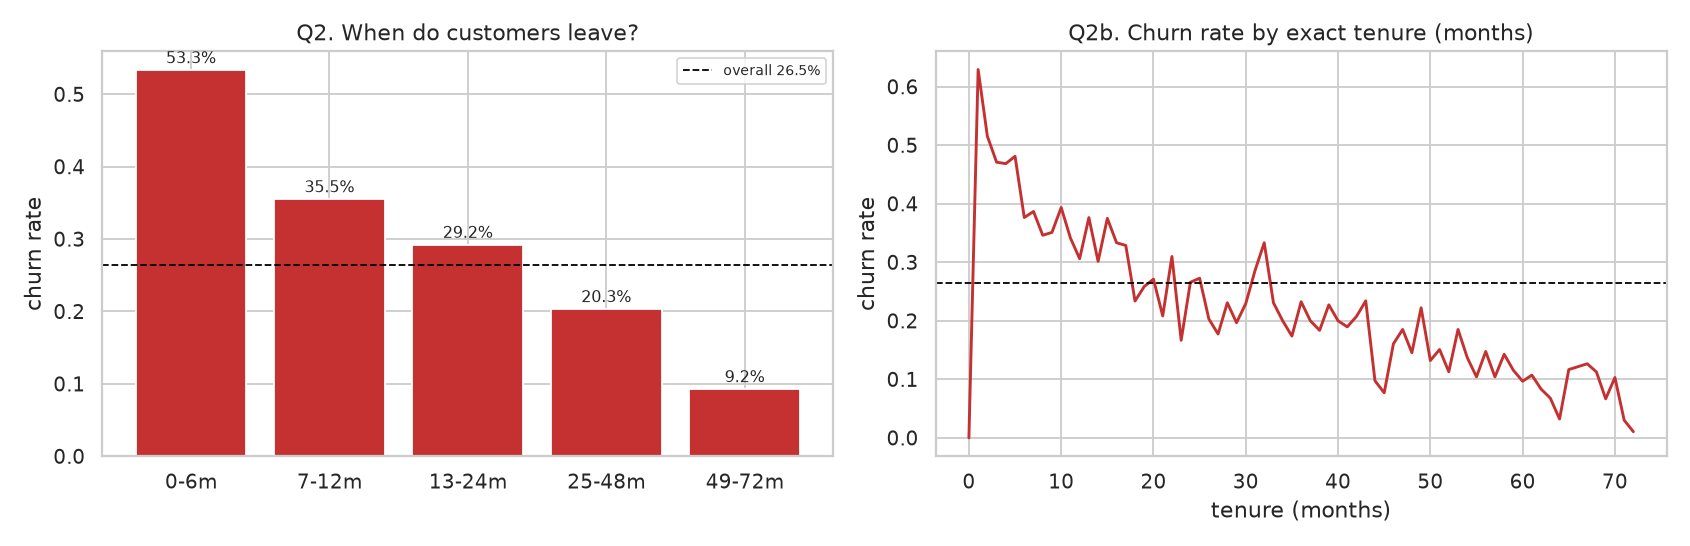

In [3]:
from IPython.display import Image, display
figdir = cfg.resolve('paths', 'figures_dir')
display(Image(str(figdir / '01_churn_overview.png')))
display(Image(str(figdir / '02_churn_by_tenure.png')))

Churn is heavily **front-loaded**. That is what motivates `tenure_band` and `is_new_customer` in the feature set, and it means a retention programme aimed at long-tenured customers is aimed at the wrong group.

## Q3: which commercial terms carry the risk?

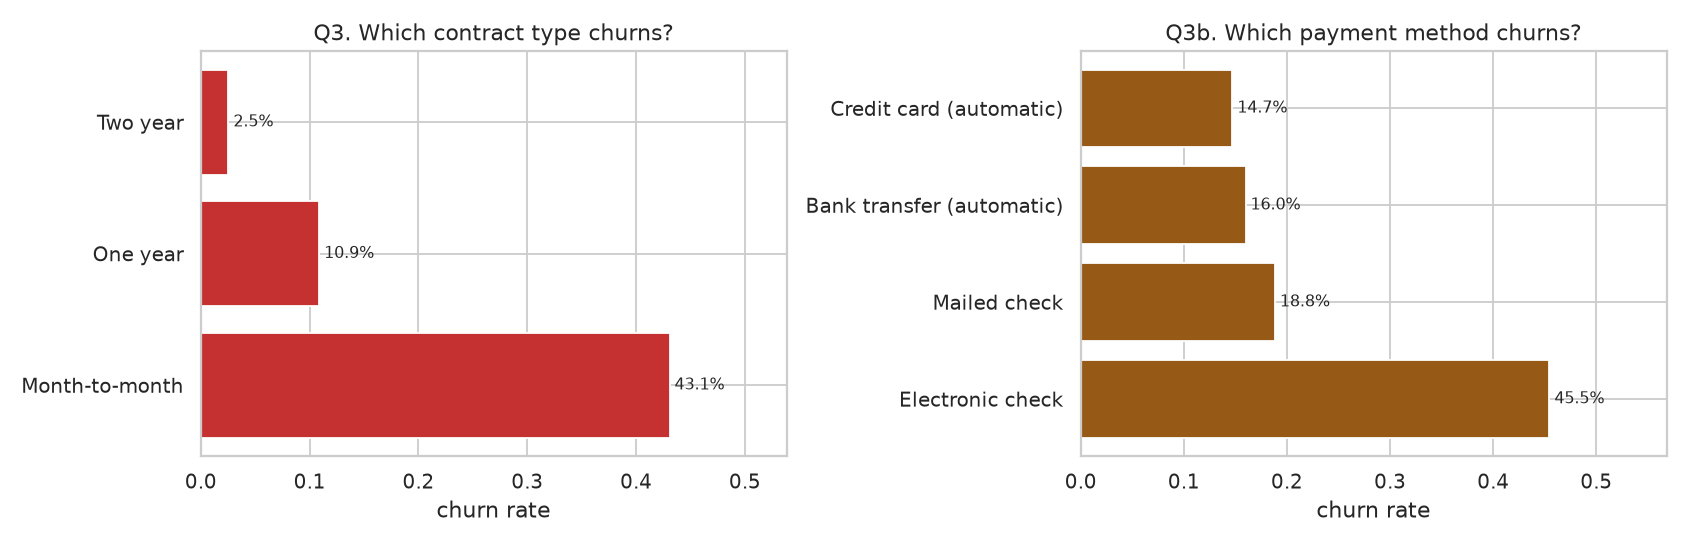

In [4]:
display(Image(str(figdir / '03_churn_by_contract_payment.png')))

## Q4: does product adoption protect against churn?

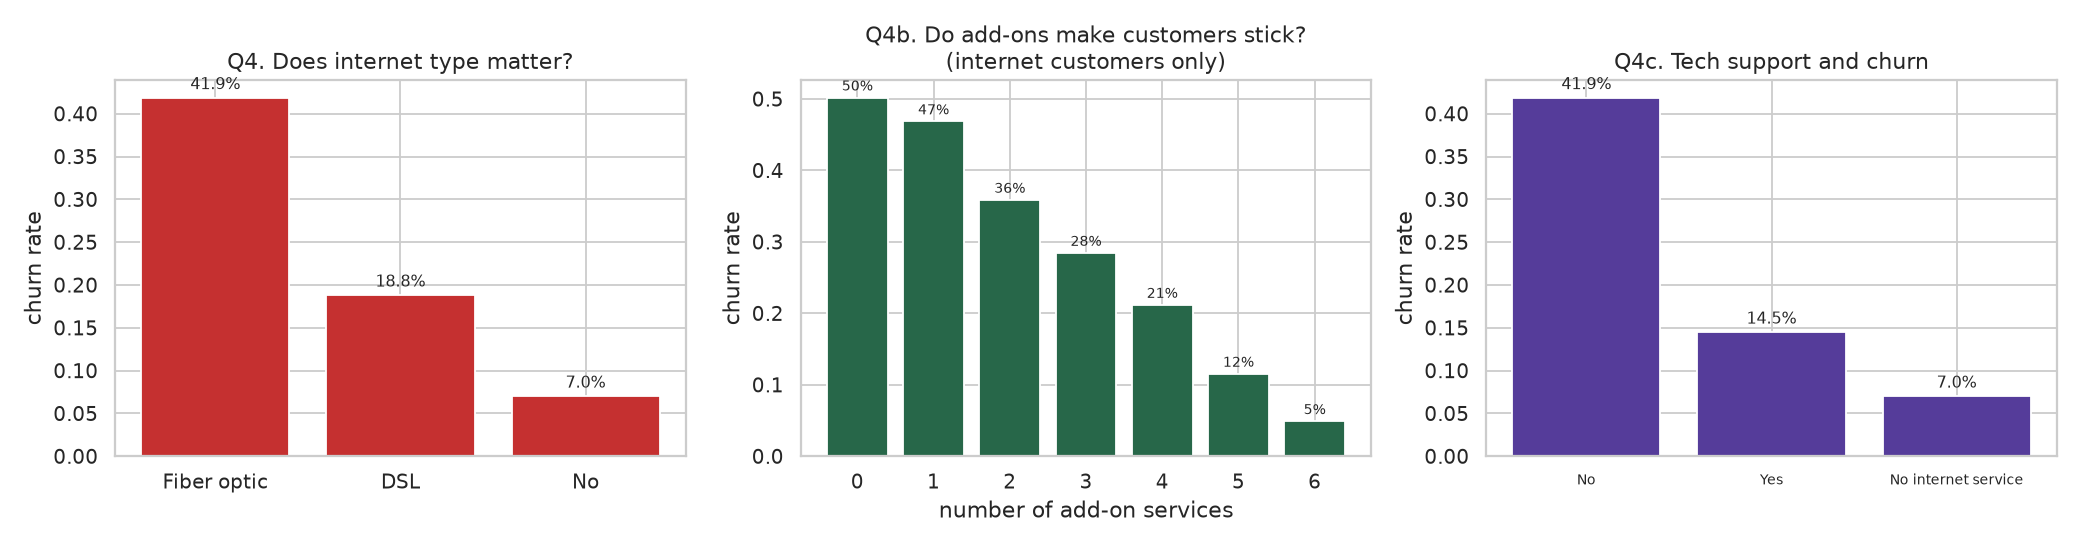

In [5]:
display(Image(str(figdir / '04_churn_by_services.png')))

In [6]:
import pandas as pd
pd.Series(findings['churn_by_n_addons'], name='churn_rate')

0    0.5018
1    0.4685
2    0.3587
3    0.2845
4    0.2117
5    0.1153
6    0.0489
Name: churn_rate, dtype: float64

Churn falls **monotonically** with add-on count. Each extra service is another switching cost. This is the clearest stickiness signal in the data and justifies `n_addons` / `addon_adoption_rate`.

## Q5–Q6: the money variables, and where risk concentrates

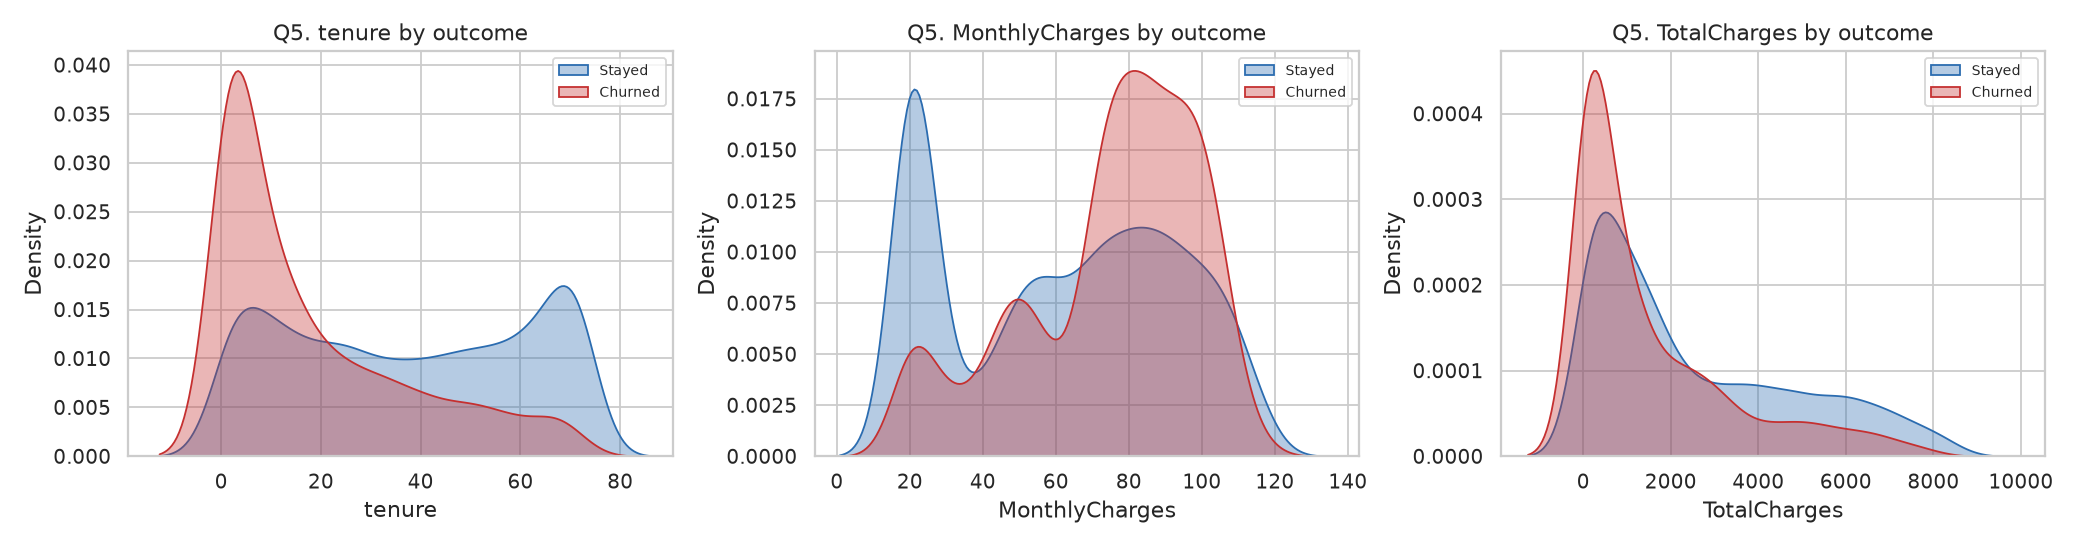

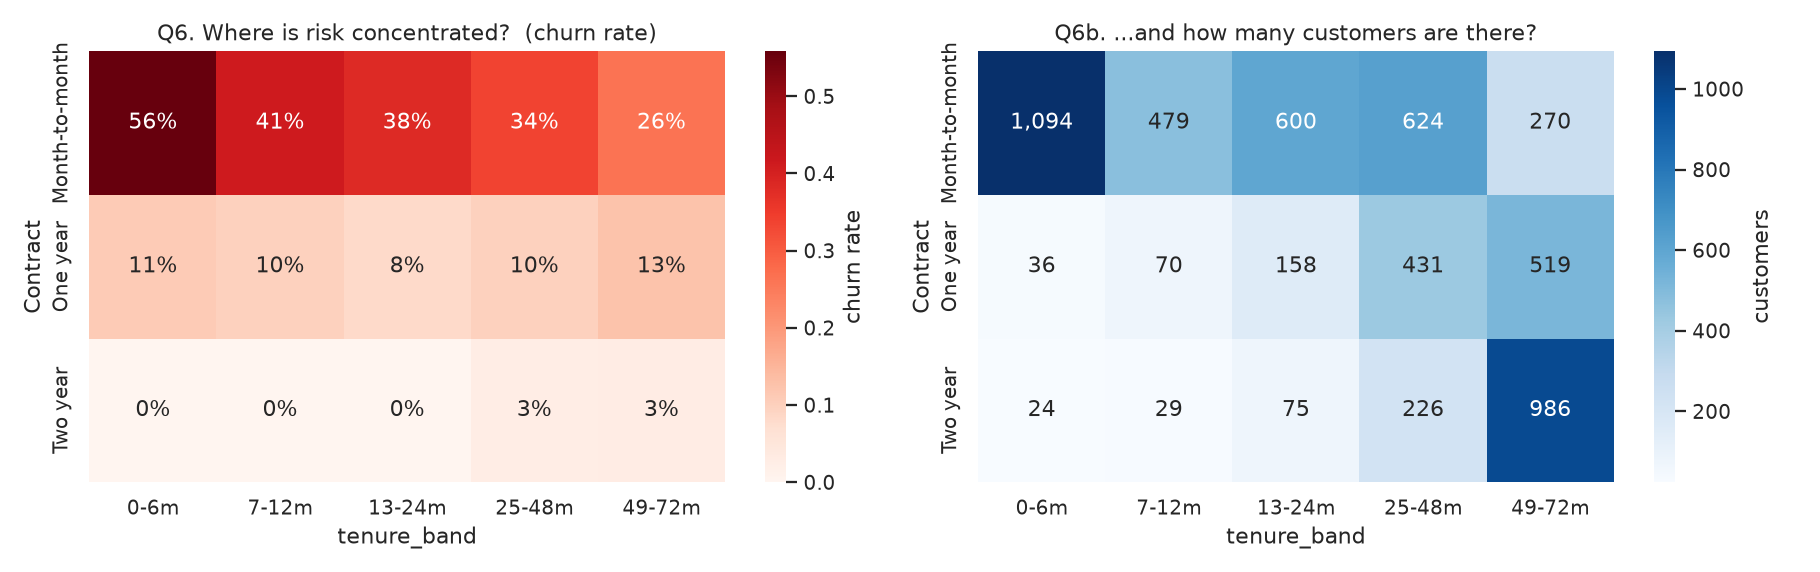

In [7]:
display(Image(str(figdir / '05_numeric_distributions.png')))
display(Image(str(figdir / '06_risk_concentration.png')))

The heatmap pair matters more than either alone: the highest-risk cell is also the **highest-volume** one, so it is where retention effort has the most to work with.